# Standard gimVI baseline for Br8667

This notebook adapts the official scvi-tools gimVI tutorial to the frozen Br8667 benchmark.

## Experiment
- **Reference:** Huuki snRNA-seq with all reference genes retained.
- **Spatial model input:** Xenium Br8667 with only the 210 training genes.
- **Development evaluation:** 45 held-out validation genes.
- **Blind test genes:** deliberately not loaded or evaluated.
- **Comparison target:** standard gimVI versus VISTA using the same gene split.

Official references:
- https://docs.scvi-tools.org/en/1.0.0/tutorials/notebooks/gimvi_tutorial.html
- https://docs.scvi-tools.org/en/1.0.0/api/reference/scvi.external.GIMVI.html


## Benchmark rules

1. Keep all 28,907 snRNA-seq genes.
2. Supply only `spatial_train_210genes.h5ad` as spatial expression input.
3. Use `validation_truth_45genes.h5ad` only after training.
4. Do not load `test_truth_45genes.h5ad`.
5. Filter zero-count cells using the allowed model inputs only.
6. Reuse the same retained spatial cells for every benchmark method.


In [ ]:
from pathlib import Path

PROJECT_ROOT = Path("/users/mjabin/projects/GeneBridge")
BASE_DIR = PROJECT_ROOT / "data/processed/imputation_beta/Br8667"

SEQ_PATH = BASE_DIR / "seq_data_huuki_snrna_Br8667_vista.h5ad"
SPATIAL_TRAIN_PATH = BASE_DIR / "benchmark/inputs/spatial_train_210genes.h5ad"
VALIDATION_TRUTH_PATH = BASE_DIR / "benchmark/truth/validation_truth_45genes.h5ad"
VALIDATION_SPLIT_PATH = BASE_DIR / "benchmark/splits/validation_genes_45.csv"
TEST_TRUTH_PATH = BASE_DIR / "benchmark/truth/test_truth_45genes.h5ad"
TEST_SPLIT_PATH = BASE_DIR / "benchmark/splits/test_genes_45.csv"
DEVELOPMENT_CELL_IDS_PATH = BASE_DIR / "benchmark/splits/development_cell_ids.csv"

OUTPUT_ROOT = PROJECT_ROOT / "outputs/imputation_beta/Br8667"
MODEL_ROOT = OUTPUT_ROOT / "models"
REPORT_DIR = OUTPUT_ROOT / "validation/gimvi"
FIGURE_DIR = REPORT_DIR / "figures"
PREDICTION_DIR = BASE_DIR / "benchmark/predictions"

for directory in [MODEL_ROOT, REPORT_DIR, FIGURE_DIR, PREDICTION_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

#RUN_MODE = "smoke"  # "smoke" or "full"
RUN_MODE = "full"  # "smoke" or "full"
RANDOM_SEED = 8667
N_LATENT = 32
BATCH_SIZE = 128
TRAIN_SIZE = 0.90
VALIDATION_SIZE = None
SMOKE_EPOCHS = 10
FULL_EPOCHS = 200
REQUIRE_GPU_FOR_FULL_RUN = True
PREDICTION_CELL_CHUNK_SIZE = 512
NORMALIZED_PREDICTIONS = False
RUN_LATENT_UMAP = False
N_VALIDATION_GENES_TO_PLOT = 4

# -----------------------------------------------------------------------------
# Blind-test safety gate
# -----------------------------------------------------------------------------
# Leave these values unchanged during development and validation.
# RUN_BLIND_TEST = False
# FINAL_CONFIGURATION_FROZEN = False
# BLIND_TEST_CONFIRMATION = ""
# BLIND_TEST_REQUIRED_PHRASE = "RUN FINAL BLIND TEST"

RUN_BLIND_TEST = True
FINAL_CONFIGURATION_FROZEN = True
BLIND_TEST_CONFIRMATION = ""
BLIND_TEST_REQUIRED_PHRASE = "RUN FINAL BLIND TEST"

if RUN_MODE not in {"smoke", "full"}:
    raise ValueError("RUN_MODE must be 'smoke' or 'full'.")

MAX_EPOCHS = SMOKE_EPOCHS if RUN_MODE == "smoke" else FULL_EPOCHS
MODEL_DIR = MODEL_ROOT / (
    "gimvi_train210_smoke" if RUN_MODE == "smoke" else "gimvi_train210_model"
)
PREDICTION_PATH = PREDICTION_DIR / (
    "gimvi_validation_predictions_45genes_smoke.h5ad"
    if RUN_MODE == "smoke"
    else "gimvi_validation_predictions_45genes.h5ad"
)

print("Run mode:", RUN_MODE)
print("Epochs:", MAX_EPOCHS)
print("Model directory:", MODEL_DIR)
print("Prediction file:", PREDICTION_PATH)
print("Run blind test:", RUN_BLIND_TEST)


Run mode: smoke
Epochs: 10
Model directory: /users/mjabin/projects/GeneBridge/outputs/imputation_beta/Br8667/models/gimvi_train210_smoke
Prediction file: /users/mjabin/projects/GeneBridge/data/processed/imputation_beta/Br8667/benchmark/predictions/gimvi_validation_predictions_45genes_smoke.h5ad
Run blind test: True


## 1. Environment and package versions

A full run requires a GPU-visible Jupyter session. The notebook prints the installed gimVI signatures before training so API/version mismatches are obvious.


In [24]:
import gc
import inspect
import platform
import sys
import time

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import scipy
from scipy import sparse
from scipy.stats import pearsonr, spearmanr
import torch

import scvi
from scvi.external import GIMVI
from IPython.display import display

scvi.settings.seed = RANDOM_SEED
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

print("Python:", sys.version.split()[0])
print("Platform:", platform.platform())
print("scvi-tools:", scvi.__version__)
print("Scanpy:", sc.__version__)
print("SciPy:", scipy.__version__)
print("PyTorch:", torch.__version__)
print("CUDA build:", torch.version.cuda)
print("CUDA available:", torch.cuda.is_available())
print("Visible GPU count:", torch.cuda.device_count())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

print("\nGIMVI constructor:")
print(inspect.signature(GIMVI))
print("\nGIMVI.train:")
print(inspect.signature(GIMVI.train))
print("\nGIMVI.get_imputed_values:")
print(inspect.signature(GIMVI.get_imputed_values))


Global seed set to 8667


Python: 3.9.23
Platform: Linux-6.12.66-88.122.amzn2023.x86_64-x86_64-with-glibc2.34
scvi-tools: 0.20.3
Scanpy: 1.9.3
SciPy: 1.10.1
PyTorch: 2.1.2+cu118
CUDA build: 11.8
CUDA available: False
Visible GPU count: 0

GIMVI constructor:
(adata_seq: anndata._core.anndata.AnnData, adata_spatial: anndata._core.anndata.AnnData, generative_distributions: Optional[List[str]] = None, model_library_size: Optional[List[bool]] = None, n_latent: int = 10, **model_kwargs)

GIMVI.train:
(self, max_epochs: int = 200, use_gpu: Union[str, int, bool, NoneType] = None, kappa: int = 5, train_size: float = 0.9, validation_size: Optional[float] = None, batch_size: int = 128, plan_kwargs: Optional[dict] = None, **kwargs)

GIMVI.get_imputed_values:
(self, adatas: List[anndata._core.anndata.AnnData] = None, deterministic: bool = True, normalized: bool = True, decode_mode: Optional[int] = None, batch_size: int = 128) -> List[numpy.ndarray]


## 2. Helper functions

The prediction helper decodes spatial cells in chunks. gimVI returns all reference genes for each requested cell; this helper keeps only the 45 validation columns and discards the large full-gene chunk immediately.


In [25]:
def to_numpy(matrix, dtype=np.float32):
    if sparse.issparse(matrix):
        matrix = matrix.toarray()
    return np.asarray(matrix, dtype=dtype)


def row_sums(matrix):
    if sparse.issparse(matrix):
        return np.asarray(matrix.sum(axis=1)).ravel()
    return np.asarray(matrix).sum(axis=1)


def validate_count_matrix(matrix, name):
    values = np.asarray(matrix.data) if sparse.issparse(matrix) else np.asarray(matrix).reshape(-1)

    if values.size == 0:
        raise ValueError(f"{name} is empty.")
    if not np.isfinite(values).all():
        raise ValueError(f"{name} contains NaN or infinite values.")
    if np.any(values < 0):
        raise ValueError(f"{name} contains negative values.")

    integer_like = bool(np.allclose(values, np.round(values), atol=1e-6))
    print(f"{name}: finite=True, nonnegative=True, integer_like={integer_like}")


def safe_pearson(x, y):
    x = np.asarray(x)
    y = np.asarray(y)
    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]

    if x.size < 3 or np.allclose(x, x[0]) or np.allclose(y, y[0]):
        return np.nan

    result = pearsonr(x, y)
    return float(result.statistic if hasattr(result, "statistic") else result[0])


def safe_spearman(x, y):
    x = np.asarray(x)
    y = np.asarray(y)
    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]

    if x.size < 3 or np.allclose(x, x[0]) or np.allclose(y, y[0]):
        return np.nan

    result = spearmanr(x, y)
    return float(result.statistic if hasattr(result, "statistic") else result[0])


def calculate_gene_metrics(observed, predicted, genes):
    if observed.shape != predicted.shape:
        raise ValueError(
            f"Shape mismatch: observed={observed.shape}, predicted={predicted.shape}"
        )

    observed_log = np.log1p(np.clip(observed, 0, None))
    predicted_log = np.log1p(np.clip(predicted, 0, None))
    records = []

    for gene_index, gene in enumerate(genes):
        obs = observed[:, gene_index]
        pred = predicted[:, gene_index]
        obs_log = observed_log[:, gene_index]
        pred_log = predicted_log[:, gene_index]

        records.append(
            {
                "gene": gene,
                "observed_mean": float(np.mean(obs)),
                "predicted_mean": float(np.mean(pred)),
                "observed_variance": float(np.var(obs)),
                "predicted_variance": float(np.var(pred)),
                "observed_nonzero_fraction": float(np.mean(obs > 0)),
                "predicted_positive_fraction": float(np.mean(pred > 0)),
                "spearman_across_cells": safe_spearman(obs, pred),
                "pearson_log1p_across_cells": safe_pearson(obs_log, pred_log),
                "mae_log1p": float(np.mean(np.abs(pred_log - obs_log))),
                "rmse_log1p": float(np.sqrt(np.mean((pred_log - obs_log) ** 2))),
                "mean_bias_log1p": float(np.mean(pred_log - obs_log)),
            }
        )

    return pd.DataFrame(records)


def calculate_pseudobulk_metrics(observed, predicted, genes, metadata, group_column):
    if group_column not in metadata.columns:
        print(f"Skipping pseudobulk: '{group_column}' is absent.")
        return pd.DataFrame()

    groups = metadata[group_column].astype(str).to_numpy()
    unique_groups = sorted(pd.unique(groups))

    observed_group_means = []
    predicted_group_means = []
    retained_groups = []

    for group in unique_groups:
        mask = groups == group
        if not np.any(mask):
            continue
        observed_group_means.append(observed[mask].mean(axis=0))
        predicted_group_means.append(predicted[mask].mean(axis=0))
        retained_groups.append(group)

    observed_group_means = np.asarray(observed_group_means)
    predicted_group_means = np.asarray(predicted_group_means)

    records = []

    for gene_index, gene in enumerate(genes):
        obs = observed_group_means[:, gene_index]
        pred = predicted_group_means[:, gene_index]
        obs_log = np.log1p(np.clip(obs, 0, None))
        pred_log = np.log1p(np.clip(pred, 0, None))

        records.append(
            {
                "gene": gene,
                "group_column": group_column,
                "n_groups": len(retained_groups),
                "groups": "|".join(retained_groups),
                "pseudobulk_spearman": safe_spearman(obs, pred),
                "pseudobulk_pearson_log1p": safe_pearson(obs_log, pred_log),
                "pseudobulk_mae_log1p": float(np.mean(np.abs(pred_log - obs_log))),
                "pseudobulk_rmse_log1p": float(
                    np.sqrt(np.mean((pred_log - obs_log) ** 2))
                ),
            }
        )

    return pd.DataFrame(records)


def save_development_cell_ids(cell_ids, path):
    new_table = pd.DataFrame({"cell_id": pd.Index(cell_ids).astype(str)})

    if path.exists():
        old_table = pd.read_csv(path)
        old_ids = old_table["cell_id"].astype(str).tolist()
        new_ids = new_table["cell_id"].astype(str).tolist()

        if old_ids != new_ids:
            raise ValueError(
                "Existing development-cell list differs from the current filter."
            )

        print("Development-cell list already exists and matches:")
        print(path)
        return

    new_table.to_csv(path, index=False)
    print("Saved development-cell list:")
    print(path)


In [26]:
@torch.inference_mode()
def predict_selected_spatial_genes_in_chunks(
    model,
    seq_adata,
    spatial_adata,
    selected_genes,
    *,
    normalized=False,
    batch_size=128,
    cell_chunk_size=None,
):
    """
    Predict selected spatial genes without retaining the complete
    cells-by-reference-genes matrix.

    This implementation follows the scvi-tools 0.20.3 GIMVI prediction loop:
    - sequencing mode = 0
    - spatial mode = 1
    - sample_scale() for normalized predictions
    - sample_rate() for non-normalized count-rate predictions

    `cell_chunk_size` is retained for notebook-call compatibility but the
    registered scvi data loader controls the actual minibatch size.
    """
    from scvi.external.gimvi._model import _unpack_tensors

    selected_genes = [str(gene) for gene in selected_genes]

    gene_positions = seq_adata.var_names.get_indexer(
        selected_genes
    )

    if np.any(gene_positions < 0):
        missing = [
            selected_genes[i]
            for i, position in enumerate(gene_positions)
            if position < 0
        ]
        raise ValueError(
            "Selected genes missing from snRNA reference: "
            f"{missing[:20]}"
        )

    # Build loaders for the original registered AnnData objects.
    # The second loader is the spatial modality and has mode=1.
    sequencing_loader, spatial_loader = model._make_scvi_dls(
        [seq_adata, spatial_adata],
        batch_size=batch_size,
    )

    del sequencing_loader

    model.module.eval()

    output = np.empty(
        (spatial_adata.n_obs, len(selected_genes)),
        dtype=np.float32,
    )

    gene_index_tensor = torch.as_tensor(
        gene_positions,
        dtype=torch.long,
        device=model.device,
    )

    processed_cells = 0
    spatial_mode = 1

    for batch_number, tensors in enumerate(
        spatial_loader,
        start=1,
    ):
        (
            sample_batch,
            batch_index,
            label,
            *_,
        ) = _unpack_tensors(tensors)

        if normalized:
            full_prediction = model.module.sample_scale(
                sample_batch,
                spatial_mode,
                batch_index,
                label,
                deterministic=True,
                decode_mode=None,
            )
        else:
            full_prediction = model.module.sample_rate(
                sample_batch,
                spatial_mode,
                batch_index,
                label,
                deterministic=True,
                decode_mode=None,
            )

        selected_prediction = (
            full_prediction
            .index_select(
                dim=1,
                index=gene_index_tensor,
            )
            .detach()
            .cpu()
            .numpy()
            .astype(np.float32, copy=False)
        )

        batch_cells = selected_prediction.shape[0]
        end = processed_cells + batch_cells

        output[
            processed_cells:end,
            :,
        ] = selected_prediction

        processed_cells = end

        del full_prediction
        del selected_prediction

        if torch.cuda.is_available():
            torch.cuda.empty_cache()

        if (
            batch_number == 1
            or batch_number % 25 == 0
            or processed_cells == spatial_adata.n_obs
        ):
            print(
                f"Processed {processed_cells:,}/"
                f"{spatial_adata.n_obs:,} spatial cells"
            )

    if processed_cells != spatial_adata.n_obs:
        raise ValueError(
            f"Predicted {processed_cells} cells, "
            f"expected {spatial_adata.n_obs}."
        )

    return output


def save_training_history(model, output_dir):
    history = model.history

    if history is None:
        print("No training history was returned.")
        return []

    try:
        history_items = history.items()
    except AttributeError:
        print("Training history is not dictionary-like:")
        print(history)
        return []

    saved_paths = []

    for key, value in history_items:
        table = pd.DataFrame(value)
        path = output_dir / f"history_{key}.csv"
        table.to_csv(path, index=True)
        saved_paths.append(path)

    print("Saved training-history tables:")
    for path in saved_paths:
        print(path)

    return saved_paths


## 3. Load the reference, training input, and validation truth

The blind test file is not loaded.


In [27]:
required_paths = [
    SEQ_PATH,
    SPATIAL_TRAIN_PATH,
    VALIDATION_TRUTH_PATH,
    VALIDATION_SPLIT_PATH,
]

for path in required_paths:
    if not path.exists():
        raise FileNotFoundError(path)

seq_data = ad.read_h5ad(SEQ_PATH)
spatial_train = ad.read_h5ad(SPATIAL_TRAIN_PATH)
validation_truth = ad.read_h5ad(VALIDATION_TRUTH_PATH)
validation_split = pd.read_csv(VALIDATION_SPLIT_PATH)

print("snRNA reference:")
print(seq_data)

print("\nSpatial training input:")
print(spatial_train)

print("\nValidation truth:")
print(validation_truth)

print("\nValidation split table:")
display(validation_split.head())


snRNA reference:
AnnData object with n_obs × n_vars = 9897 × 28907
    obs: 'Sample', 'Barcode', 'key', 'SAMPLE_ID', 'pos', 'BrNum', 'round', 'Position', 'age', 'sex', 'diagnosis', 'sum', 'detected', 'subsets_Mito_sum', 'subsets_Mito_detected', 'subsets_Mito_percent', 'total', 'high_mito', 'low_sum', 'low_detected', 'discard_auto', 'doubletScore', 'prelimCluster', 'collapsedCluster', 'kmeans', 'sizeFactor', 'cellType_broad_k', 'cellType_k', 'cellType_broad_hc', 'cellType_hc', 'cellType_layer', 'layer_annotation', 'scClassify_original', 'scClassify', 'names', 'batch'
    var: 'source', 'type', 'gene_id', 'gene_version', 'gene_name', 'gene_type', 'binomial_deviance', 'matched_gene_symbol', 'original_var_name', 'vista_gene_symbol'
    uns: 'Samples', 'X_name', 'cell_type_colors', 'cell_type_colors_broad', 'vista_expression_matrix'
    obsm: 'GLMPCA_approx', 'HARMONY', 'TSNE', 'UMAP'

Spatial training input:
AnnData object with n_obs × n_vars = 66164 × 210
    obs: 'cell_id', 'x_centroid',

,gene,split,expression_stratum,expression_stratum_number,mean_expression,variance_expression,detected_cell_count,detection_fraction,log1p_mean_expression,log1p_variance_expression,mean_percentile,variance_percentile,detection_percentile,composite_expression_score
0,ALOX5AP,validation,S1_lowest,1,0.144401,0.414969,5036,0.076114,0.134881,0.347108,0.153333,0.180000,0.116667,0.150000
1,IGFBP6,validation,S1_lowest,1,0.138313,0.223517,7225,0.109198,0.129548,0.201729,0.143333,0.103333,0.183333,0.143333
2,LILRB4,validation,S1_lowest,1,0.101688,0.252306,3748,0.056647,0.096844,0.224987,0.083333,0.116667,0.076667,0.092222
3,NXPH4,validation,S1_lowest,1,0.042545,0.096205,1844,0.027870,0.041665,0.091854,0.030000,0.046667,0.030000,0.035556
4,SMIM32,validation,S1_lowest,1,0.059594,0.476843,1684,0.025452,0.057886,0.389907,0.046667,0.203333,0.026667,0.092222


## 4. Validate the benchmark design

Expected:
- snRNA: approximately `9,897 × 28,907`
- spatial training input: `66,164 × 210`
- validation truth: `66,164 × 45`
- training and validation gene sets are disjoint
- all 255 genes are present in the snRNA reference
- spatial and validation cell order is identical


In [28]:
train_genes = spatial_train.var_names.astype(str).tolist()
validation_genes = validation_truth.var_names.astype(str).tolist()
seq_genes = set(seq_data.var_names.astype(str))

checks = {
    "spatial_training_genes_is_210": spatial_train.n_vars == 210,
    "validation_genes_is_45": validation_truth.n_vars == 45,
    "training_validation_disjoint": set(train_genes).isdisjoint(validation_genes),
    "all_training_genes_in_snrna": set(train_genes).issubset(seq_genes),
    "all_validation_genes_in_snrna": set(validation_genes).issubset(seq_genes),
    "same_spatial_validation_cells": spatial_train.obs_names.equals(
        validation_truth.obs_names
    ),
    "spatial_coordinates_present": "spatial" in spatial_train.obsm,
    "spatial_coordinates_shape_correct": (
        "spatial" in spatial_train.obsm
        and spatial_train.obsm["spatial"].shape == (spatial_train.n_obs, 2)
    ),
}

print("Benchmark validation:")
for name, passed in checks.items():
    print(f"{name}: {passed}")

if not all(checks.values()):
    failed = [name for name, passed in checks.items() if not passed]
    raise ValueError(f"Benchmark validation failed: {failed}")

validate_count_matrix(seq_data.X, "snRNA .X")
validate_count_matrix(spatial_train.X, "Spatial training .X")
validate_count_matrix(validation_truth.X, "Validation truth .X")

validation_split_genes = validation_split["gene"].astype(str).tolist()

if set(validation_split_genes) != set(validation_genes):
    raise ValueError(
        "Validation split CSV and validation-truth h5ad contain different genes."
    )

print("\nPASS: benchmark inputs are structurally valid.")


Benchmark validation:
spatial_training_genes_is_210: True
validation_genes_is_45: True
training_validation_disjoint: True
all_training_genes_in_snrna: True
all_validation_genes_in_snrna: True
same_spatial_validation_cells: True
spatial_coordinates_present: True
spatial_coordinates_shape_correct: True
snRNA .X: finite=True, nonnegative=True, integer_like=True
Spatial training .X: finite=True, nonnegative=True, integer_like=True
Validation truth .X: finite=True, nonnegative=True, integer_like=True

PASS: benchmark inputs are structurally valid.


## 5. Remove zero-input cells without using validation truth

The zero-count decision uses only:
- all genes in the snRNA reference for snRNA nuclei;
- the 210 allowed training genes for Xenium cells.

Validation rows are then aligned to the retained spatial cells.


In [29]:
seq_totals = row_sums(seq_data.X)
spatial_train_totals = row_sums(spatial_train.X)

seq_keep = seq_totals > 0
spatial_keep = spatial_train_totals > 0

print("Empty snRNA nuclei before filtering:", int((~seq_keep).sum()))
print(
    "Empty Xenium cells across 210 training genes:",
    int((~spatial_keep).sum()),
)

seq_data = seq_data[seq_keep].copy()
kept_spatial_cells = spatial_train.obs_names[spatial_keep]

spatial_train = spatial_train[kept_spatial_cells].copy()
validation_truth = validation_truth[kept_spatial_cells].copy()

save_development_cell_ids(
    kept_spatial_cells,
    DEVELOPMENT_CELL_IDS_PATH,
)

assert spatial_train.obs_names.equals(validation_truth.obs_names)

print("\nAfter input-only filtering:")
print("snRNA:", seq_data.shape)
print("Spatial training:", spatial_train.shape)
print("Validation truth:", validation_truth.shape)


Empty snRNA nuclei before filtering: 0
Empty Xenium cells across 210 training genes: 10
Development-cell list already exists and matches:
/users/mjabin/projects/GeneBridge/data/processed/imputation_beta/Br8667/benchmark/splits/development_cell_ids.csv

After input-only filtering:
snRNA: (9897, 28907)
Spatial training: (66154, 210)
Validation truth: (66154, 45)


## 6. Register the two model inputs

Raw counts are already in `.X`, so `layer=None`. Cell-type labels remain in `.obs` for evaluation but are not required by standard gimVI.


In [30]:
seq_batch_key = "batch" if "batch" in seq_data.obs.columns else None
spatial_batch_key = (
    "batch" if "batch" in spatial_train.obs.columns else None
)

print("snRNA batch key:", seq_batch_key)
print("Spatial batch key:", spatial_batch_key)

GIMVI.setup_anndata(
    seq_data,
    batch_key=seq_batch_key,
    layer=None,
)

GIMVI.setup_anndata(
    spatial_train,
    batch_key=spatial_batch_key,
    layer=None,
)

print("\nRegistration completed successfully.")
print("snRNA shape:", seq_data.shape)
print("Spatial training shape:", spatial_train.shape)

if seq_batch_key is not None:
    print("\nsnRNA batch counts:")
    print(
        seq_data.obs[seq_batch_key]
        .astype(str)
        .value_counts(dropna=False)
    )

if spatial_batch_key is not None:
    print("\nSpatial batch counts:")
    print(
        spatial_train.obs[spatial_batch_key]
        .astype(str)
        .value_counts(dropna=False)
    )


snRNA batch key: batch
Spatial batch key: batch

Registration completed successfully.
snRNA shape: (9897, 28907)
Spatial training shape: (66154, 210)

snRNA batch counts:
Br8667_snrna    9897
Name: batch, dtype: int64

Spatial batch counts:
Br8667_xenium    66154
Name: batch, dtype: int64


## 7. Construct standard gimVI

`n_latent=32` matches VISTA. Standard gimVI does not use a spatial graph, neighbor size, or graph convolution.


In [31]:
model = GIMVI(
    seq_data,
    spatial_train,
    n_latent=N_LATENT,
)

print(model)
print("\nModel device before training:", model.device)


GimVI Model with the following params: 
n_latent: 32, n_inputs: [28907, 210], n_genes: 28907, n_batch: 2, generative distributions: ['zinb', 'nb']
Training status: Not Trained
Model's adata is minified?: False



Model device before training: cpu


## 8. Train

- `RUN_MODE="smoke"`: two CPU epochs.
- `RUN_MODE="full"`: 200 GPU epochs.

After a smoke test, restart the kernel and rerun with `RUN_MODE="full"` so the final model starts from a fresh initialization.


In [32]:
# if (
#     RUN_MODE == "full"
#     and REQUIRE_GPU_FOR_FULL_RUN
#     and not torch.cuda.is_available()
# ):
#     raise RuntimeError(
#         "Full training requires a visible GPU, but "
#         "torch.cuda.is_available() is False."
#     )

# scvi-tools 0.20.x GIMVI interface:
# False -> CPU
# "cuda:0" -> first visible GPU
use_gpu = False if RUN_MODE == "smoke" else "cuda:0"

print("Training configuration:")
print("  mode:", RUN_MODE)
print("  epochs:", MAX_EPOCHS)
print("  use_gpu:", use_gpu)
print("  batch size:", BATCH_SIZE)
print("  cell train size:", TRAIN_SIZE)
print("  cell validation size:", VALIDATION_SIZE)

training_start = time.time()

model.train(
    max_epochs=MAX_EPOCHS,
    use_gpu=use_gpu,
    train_size=TRAIN_SIZE,
    validation_size=VALIDATION_SIZE,
    batch_size=BATCH_SIZE,
    check_val_every_n_epoch=1,
)

training_seconds = time.time() - training_start

print(
    f"Training completed in "
    f"{training_seconds / 60:.2f} minutes."
)
print("Model trained:", model.is_trained)
print("Model device:", model.device)


/scratch/mjabin/conda_envs/Imputation/lib/python3.9/site-packages/lightning_fabric/plugins/environments/slurm.py:165: PossibleUserWarning: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /scratch/mjabin/conda_envs/Imputation/lib/python3.9/ ...
  rank_zero_warn(
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs


Training configuration:
  mode: smoke
  epochs: 10
  use_gpu: False
  batch size: 128
  cell train size: 0.9
  cell validation size: None


/scratch/mjabin/conda_envs/Imputation/lib/python3.9/site-packages/lightning_fabric/plugins/environments/slurm.py:165: PossibleUserWarning: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /scratch/mjabin/conda_envs/Imputation/lib/python3.9/ ...
  rank_zero_warn(


Epoch 10/10: 100%|██████████| 10/10 [10:38<00:00, 63.83s/it, loss=3.53e+03, v_num=1]

`Trainer.fit` stopped: `max_epochs=10` reached.


Epoch 10/10: 100%|██████████| 10/10 [10:38<00:00, 63.89s/it, loss=3.53e+03, v_num=1]
Training completed in 10.65 minutes.
Model trained: True
Model device: cpu


## Training-history curves

This cell plots every metric that your installed gimVI version actually records in `model.history`.
Your version may record validation loss only; that is normal. gimVI does not produce a classification-accuracy curve.


Available model.history metrics:
  elbo_validation: 10 recorded epochs
  reconstruction_loss_validation: 10 recorded epochs
  kl_local_validation: 10 recorded epochs
  kl_global_validation: 10 recorded epochs


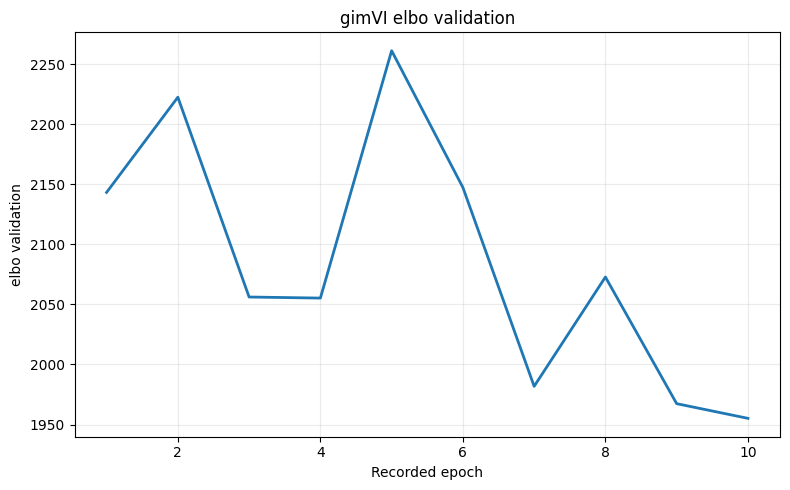

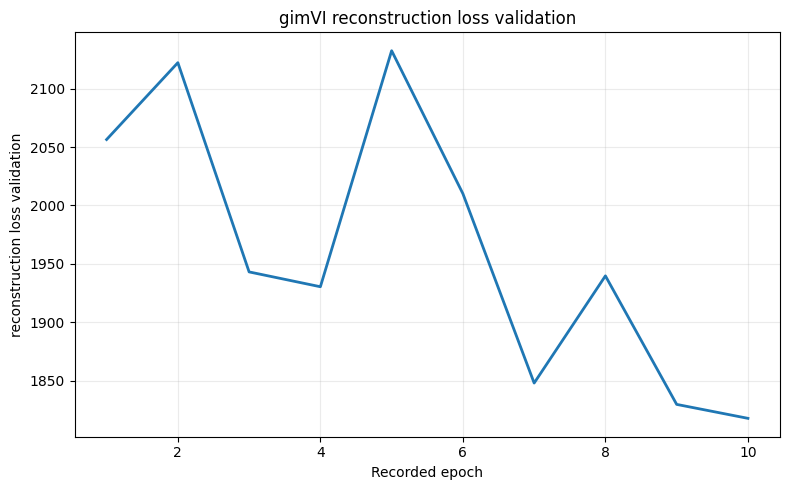

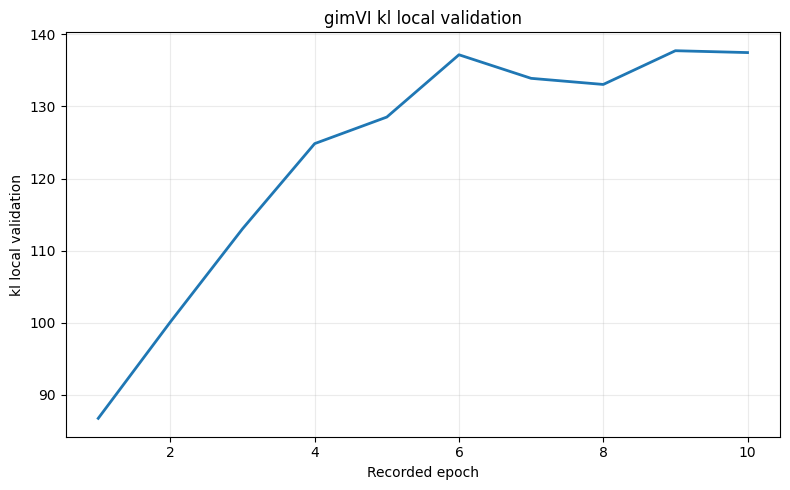

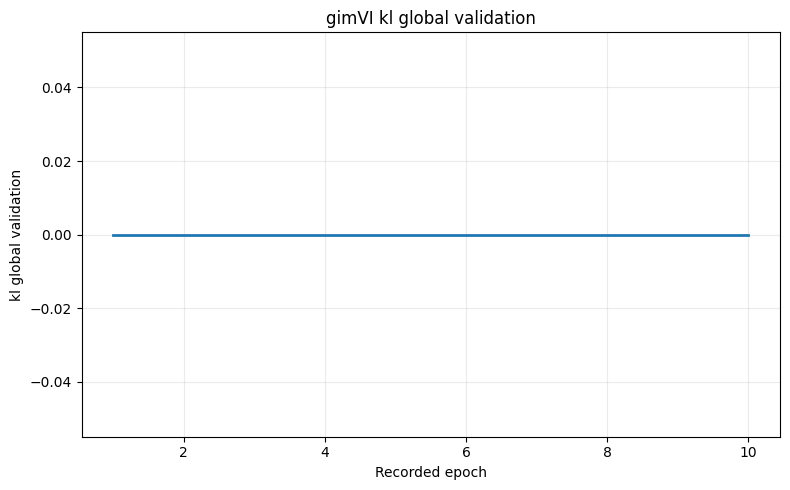


Created loss figures:
/users/mjabin/projects/GeneBridge/outputs/imputation_beta/Br8667/validation/gimvi/training_curves/12_gimvi_elbo_validation.png
/users/mjabin/projects/GeneBridge/outputs/imputation_beta/Br8667/validation/gimvi/training_curves/12_gimvi_reconstruction_loss_validation.png
/users/mjabin/projects/GeneBridge/outputs/imputation_beta/Br8667/validation/gimvi/training_curves/12_gimvi_kl_local_validation.png
/users/mjabin/projects/GeneBridge/outputs/imputation_beta/Br8667/validation/gimvi/training_curves/12_gimvi_kl_global_validation.png

Saved history CSV:
/users/mjabin/projects/GeneBridge/outputs/imputation_beta/Br8667/validation/gimvi/training_curves/12_gimvi_training_history.csv

Note: this gimVI version recorded validation metrics only, so no training-loss line is available.


In [33]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch


LOSS_CURVE_DIR = (
    OUTPUT_ROOT
    / "validation/gimvi/training_curves"
)
LOSS_CURVE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


def _scalar_to_float(value):
    """Convert tensor/NumPy/Python scalar to float."""
    if torch.is_tensor(value):
        value = value.detach().cpu()

        if value.numel() != 1:
            return np.nan

        return float(value.item())

    if isinstance(value, np.ndarray):
        if value.size != 1:
            return np.nan

        return float(value.reshape(-1)[0])

    if isinstance(value, (list, tuple)):
        if len(value) != 1:
            return np.nan

        return _scalar_to_float(value[0])

    try:
        return float(value)
    except (TypeError, ValueError):
        return np.nan


def _history_to_series(history_value):
    """
    Convert a scvi-tools history object to a numeric Series.

    Handles object-dtype DataFrames containing tensors.
    """
    if isinstance(history_value, pd.DataFrame):
        raw_values = history_value.to_numpy(
            dtype=object
        ).reshape(-1)

    elif isinstance(history_value, pd.Series):
        raw_values = history_value.to_numpy(
            dtype=object
        ).reshape(-1)

    else:
        raw_values = np.asarray(
            history_value,
            dtype=object,
        ).reshape(-1)

    numeric_values = [
        _scalar_to_float(value)
        for value in raw_values
    ]

    numeric_values = [
        value
        for value in numeric_values
        if np.isfinite(value)
    ]

    return pd.Series(
        numeric_values,
        index=np.arange(
            1,
            len(numeric_values) + 1,
        ),
        dtype=float,
    )


history = model.history

if history is None or len(history) == 0:
    raise RuntimeError(
        "model.history is empty. Run this cell immediately "
        "after model.train() in the same kernel."
    )

parsed_history = {}

print("Available model.history metrics:")

for metric_name, history_value in history.items():
    series = _history_to_series(
        history_value
    )

    if len(series) == 0:
        print(
            f"  {metric_name}: skipped "
            "(no scalar numeric values)"
        )
        continue

    parsed_history[metric_name] = series

    print(
        f"  {metric_name}: "
        f"{len(series)} recorded epochs"
    )

if not parsed_history:
    raise RuntimeError(
        "No plottable numeric metrics were found "
        "in model.history."
    )


# Save all parsed history values.
history_table = pd.concat(
    [
        pd.DataFrame(
            {
                "epoch": series.index,
                "metric": metric_name,
                "value": series.values,
            }
        )
        for metric_name, series
        in parsed_history.items()
    ],
    ignore_index=True,
)

HISTORY_CSV_PATH = (
    LOSS_CURVE_DIR
    / "12_gimvi_training_history.csv"
)

history_table.to_csv(
    HISTORY_CSV_PATH,
    index=False,
)


# Plot each recorded metric separately.
created_figures = []

for metric_name, series in parsed_history.items():
    readable_name = metric_name.replace(
        "_",
        " ",
    )

    plt.figure(figsize=(8, 5))

    plt.plot(
        series.index,
        series.values,
        linewidth=2,
    )

    plt.xlabel("Recorded epoch")
    plt.ylabel(readable_name)
    plt.title(f"gimVI {readable_name}")
    plt.grid(alpha=0.25)
    plt.tight_layout()

    safe_name = re.sub(
        r"[^A-Za-z0-9_.-]+",
        "_",
        metric_name,
    )

    figure_path = (
        LOSS_CURVE_DIR
        / f"12_gimvi_{safe_name}.png"
    )

    plt.savefig(
        figure_path,
        dpi=220,
        bbox_inches="tight",
    )

    plt.show()
    plt.close()

    created_figures.append(
        figure_path
    )


print("\nCreated loss figures:")
for figure_path in created_figures:
    print(figure_path)

print("\nSaved history CSV:")
print(HISTORY_CSV_PATH)

if not any(
    metric_name.endswith("_train")
    for metric_name in parsed_history
):
    print(
        "\nNote: this gimVI version recorded validation "
        "metrics only, so no training-loss line is available."
    )


## 9. Save the model and run metadata

The model is saved before prediction. Smoke and full runs use separate directories.


In [34]:
model.save(
    MODEL_DIR,
    overwrite=True,
    save_anndata=False,
)

history_paths = save_training_history(model, REPORT_DIR)

run_metadata = pd.DataFrame(
    [
        {"field": "run_mode", "value": RUN_MODE},
        {"field": "random_seed", "value": RANDOM_SEED},
        {"field": "epochs", "value": MAX_EPOCHS},
        {"field": "n_latent", "value": N_LATENT},
        {"field": "batch_size", "value": BATCH_SIZE},
        {"field": "train_size", "value": TRAIN_SIZE},
        {"field": "validation_size", "value": VALIDATION_SIZE},
        {
            "field": "normalized_predictions",
            "value": NORMALIZED_PREDICTIONS,
        },
        {"field": "retained_snrna_nuclei", "value": seq_data.n_obs},
        {"field": "retained_spatial_cells", "value": spatial_train.n_obs},
        {"field": "spatial_training_genes", "value": spatial_train.n_vars},
        {"field": "validation_genes", "value": validation_truth.n_vars},
        {"field": "training_seconds", "value": training_seconds},
        {"field": "scvi_tools_version", "value": scvi.__version__},
        {"field": "torch_version", "value": torch.__version__},
    ]
)

RUN_METADATA_PATH = REPORT_DIR / "12_gimvi_run_metadata.csv"
run_metadata.to_csv(RUN_METADATA_PATH, index=False)

print("Saved model:")
print(MODEL_DIR)
print("\nSaved run metadata:")
print(RUN_METADATA_PATH)


Saved training-history tables:
/users/mjabin/projects/GeneBridge/outputs/imputation_beta/Br8667/validation/gimvi/history_elbo_validation.csv
/users/mjabin/projects/GeneBridge/outputs/imputation_beta/Br8667/validation/gimvi/history_reconstruction_loss_validation.csv
/users/mjabin/projects/GeneBridge/outputs/imputation_beta/Br8667/validation/gimvi/history_kl_local_validation.csv
/users/mjabin/projects/GeneBridge/outputs/imputation_beta/Br8667/validation/gimvi/history_kl_global_validation.csv
Saved model:
/users/mjabin/projects/GeneBridge/outputs/imputation_beta/Br8667/models/gimvi_train210_smoke

Saved run metadata:
/users/mjabin/projects/GeneBridge/outputs/imputation_beta/Br8667/validation/gimvi/12_gimvi_run_metadata.csv


## 10. Inspect the internal cell split

This is the internal 90/10 cell split for optimization. It is separate from the fixed `210/45/45` gene split.


In [35]:
print("Training cells/nuclei by modality:")
for modality, indices in zip(["snRNA", "spatial"], model.train_indices):
    print(modality, len(indices))

print("\nValidation cells/nuclei by modality:")
for modality, indices in zip(["snRNA", "spatial"], model.validation_indices):
    print(modality, len(indices))

print("\nTest cells/nuclei by modality:")
for modality, indices in zip(["snRNA", "spatial"], model.test_indices):
    print(modality, len(indices))


Training cells/nuclei by modality:
snRNA 8908
spatial 59539

Validation cells/nuclei by modality:
snRNA 989
spatial 6615

Test cells/nuclei by modality:
snRNA 0
spatial 0


## 11. Predict the 45 validation genes

Only the validation columns are retained. The full 28,907-gene result for each chunk is deleted immediately.


In [36]:
validation_genes = validation_truth.var_names.astype(str).tolist()

prediction_start = time.time()

validation_prediction = predict_selected_spatial_genes_in_chunks(
    model=model,
    seq_adata=seq_data,
    spatial_adata=spatial_train,
    selected_genes=validation_genes,
    normalized=NORMALIZED_PREDICTIONS,
    batch_size=BATCH_SIZE,
    cell_chunk_size=PREDICTION_CELL_CHUNK_SIZE,
)

prediction_seconds = time.time() - prediction_start

print("\nValidation prediction shape:", validation_prediction.shape)
print(f"Prediction completed in {prediction_seconds / 60:.2f} minutes.")

if not np.isfinite(validation_prediction).all():
    raise ValueError("Validation predictions contain NaN or infinity.")
if np.any(validation_prediction < 0):
    raise ValueError("Validation predictions contain negative values.")

print(
    "All-zero predicted cells:",
    int(np.sum(validation_prediction.sum(axis=1) == 0)),
)
print(
    "All-zero predicted validation genes:",
    int(np.sum(validation_prediction.sum(axis=0) == 0)),
)


Processed 128/66,154 spatial cells
Processed 3,200/66,154 spatial cells
Processed 6,400/66,154 spatial cells
Processed 9,600/66,154 spatial cells
Processed 12,800/66,154 spatial cells
Processed 16,000/66,154 spatial cells
Processed 19,200/66,154 spatial cells
Processed 22,400/66,154 spatial cells
Processed 25,600/66,154 spatial cells
Processed 28,800/66,154 spatial cells
Processed 32,000/66,154 spatial cells
Processed 35,200/66,154 spatial cells
Processed 38,400/66,154 spatial cells
Processed 41,600/66,154 spatial cells
Processed 44,800/66,154 spatial cells
Processed 48,000/66,154 spatial cells
Processed 51,200/66,154 spatial cells
Processed 54,400/66,154 spatial cells
Processed 57,600/66,154 spatial cells
Processed 60,800/66,154 spatial cells
Processed 64,000/66,154 spatial cells
Processed 66,154/66,154 spatial cells

Validation prediction shape: (66154, 45)
Prediction completed in 0.06 minutes.
All-zero predicted cells: 0
All-zero predicted validation genes: 0


## 12. Save validation predictions

The output contains only 45 held-out validation genes and the retained development cells.


In [37]:
validation_prediction_adata = ad.AnnData(
    X=validation_prediction.astype(np.float32, copy=False),
    obs=spatial_train.obs.copy(),
    var=validation_truth.var.copy(),
)

validation_prediction_adata.obsm["spatial"] = (
    spatial_train.obsm["spatial"].copy()
)

validation_prediction_adata.uns["method"] = "standard_gimVI"
validation_prediction_adata.uns["benchmark_role"] = "validation_prediction"
validation_prediction_adata.uns["training_spatial_genes"] = int(
    spatial_train.n_vars
)
validation_prediction_adata.uns["validation_genes"] = int(
    validation_truth.n_vars
)
validation_prediction_adata.uns["normalized_predictions"] = bool(
    NORMALIZED_PREDICTIONS
)
validation_prediction_adata.uns["run_mode"] = RUN_MODE

validation_prediction_adata.write_h5ad(
    PREDICTION_PATH,
    compression="gzip",
)

print("Saved validation predictions:")
print(PREDICTION_PATH)
print("File size MB:", PREDICTION_PATH.stat().st_size / (1024**2))


Saved validation predictions:
/users/mjabin/projects/GeneBridge/data/processed/imputation_beta/Br8667/benchmark/predictions/gimvi_validation_predictions_45genes_smoke.h5ad
File size MB: 26.228919982910156


## 13. Evaluate held-out validation genes

Primary metric:
- median per-gene Spearman correlation across spatial cells.

Secondary metrics:
- Pearson correlation on `log1p`;
- MAE on `log1p`;
- RMSE on `log1p`;
- observed and predicted detection summaries.


In [38]:
observed_validation = to_numpy(
    validation_truth.X,
    dtype=np.float32,
)

gene_metrics = calculate_gene_metrics(
    observed=observed_validation,
    predicted=validation_prediction,
    genes=validation_genes,
)

merge_columns = [
    column
    for column in [
        "gene",
        "expression_stratum",
        "expression_stratum_number",
        "mean_expression",
        "detection_fraction",
    ]
    if column in validation_split.columns
]

gene_metrics = gene_metrics.merge(
    validation_split[merge_columns],
    on="gene",
    how="left",
    suffixes=("", "_split"),
)

GENE_METRICS_PATH = REPORT_DIR / "13_gimvi_validation_gene_metrics.csv"
gene_metrics.to_csv(GENE_METRICS_PATH, index=False)

summary = pd.DataFrame(
    [
        {
            "metric": "n_validation_genes",
            "value": len(gene_metrics),
        },
        {
            "metric": "median_spearman_across_genes",
            "value": gene_metrics["spearman_across_cells"].median(skipna=True),
        },
        {
            "metric": "median_pearson_log1p_across_genes",
            "value": gene_metrics[
                "pearson_log1p_across_cells"
            ].median(skipna=True),
        },
        {
            "metric": "median_mae_log1p_across_genes",
            "value": gene_metrics["mae_log1p"].median(skipna=True),
        },
        {
            "metric": "median_rmse_log1p_across_genes",
            "value": gene_metrics["rmse_log1p"].median(skipna=True),
        },
        {
            "metric": "mean_spearman_across_genes",
            "value": gene_metrics["spearman_across_cells"].mean(skipna=True),
        },
        {
            "metric": "genes_with_finite_spearman",
            "value": gene_metrics["spearman_across_cells"].notna().sum(),
        },
        {
            "metric": "all_zero_predicted_cells",
            "value": int(np.sum(validation_prediction.sum(axis=1) == 0)),
        },
        {
            "metric": "all_zero_predicted_genes",
            "value": int(np.sum(validation_prediction.sum(axis=0) == 0)),
        },
    ]
)

SUMMARY_PATH = REPORT_DIR / "13_gimvi_validation_summary.csv"
summary.to_csv(SUMMARY_PATH, index=False)

print("Validation summary:")
display(summary)

print("\nBest validation genes by Spearman:")
display(
    gene_metrics.sort_values(
        "spearman_across_cells",
        ascending=False,
    ).head(10)
)

print("\nLowest validation genes by Spearman:")
display(
    gene_metrics.sort_values(
        "spearman_across_cells",
        ascending=True,
    ).head(10)
)

print("\nSaved:")
print(GENE_METRICS_PATH)
print(SUMMARY_PATH)


Validation summary:


,metric,value
0,n_validation_genes,45.000000
1,median_spearman_across_genes,0.217045
2,median_pearson_log1p_across_genes,0.244629
3,median_mae_log1p_across_genes,0.417879
4,median_rmse_log1p_across_genes,0.557038
5,mean_spearman_across_genes,0.317814
6,genes_with_finite_spearman,45.000000
7,all_zero_predicted_cells,0.000000
8,all_zero_predicted_genes,0.000000



Best validation genes by Spearman:


,gene,observed_mean,predicted_mean,observed_variance,predicted_variance,observed_nonzero_fraction,predicted_positive_fraction,spearman_across_cells,pearson_log1p_across_cells,mae_log1p,rmse_log1p,mean_bias_log1p,expression_stratum,expression_stratum_number,mean_expression,detection_fraction
27,MT-ND4,61.346901,27.343300,1495.842407,286.163757,0.996266,1.0,0.892280,0.918651,0.760220,0.818041,-0.745624,S5_highest,5,61.337800,0.996116
15,ENC1,8.161396,8.527616,220.017807,91.304817,0.681561,1.0,0.797379,0.804767,0.719719,0.896720,0.485715,S5_highest,5,8.160025,0.681458
31,OGA,5.153913,3.716879,34.229481,15.226920,0.845164,1.0,0.788934,0.815041,0.445261,0.545147,-0.137592,S5_highest,5,5.152765,0.845037
12,CSMD1,3.482208,76.486176,41.000420,12088.886719,0.489404,1.0,0.770430,0.792021,2.573589,2.723110,2.573403,S5_highest,5,3.481564,0.489330
21,KIF1A,5.835263,4.620356,40.272491,16.937157,0.833222,1.0,0.765247,0.768057,0.496671,0.614333,-0.015822,S5_highest,5,5.834047,0.833097
33,PSMA7,3.077214,1.119288,10.824978,0.686703,0.793799,1.0,0.704359,0.711816,0.600724,0.715916,-0.431961,S5_highest,5,3.076810,0.793679
14,EGR3,1.594129,0.546956,11.233431,0.313574,0.413656,1.0,0.662203,0.749366,0.434926,0.606411,-0.162031,S4_high,4,1.594090,0.413593
18,GRIN2A,0.672884,21.760509,2.346544,754.074341,0.272168,1.0,0.657465,0.666322,2.067375,2.292989,2.067217,S3_medium,3,0.672800,0.272127
7,BLCAP,1.247105,1.169168,3.145533,1.262766,0.526287,1.0,0.624432,0.673099,0.395974,0.480656,0.087896,S4_high,4,1.247165,0.526208
10,CHST1,2.071198,0.701135,11.627937,0.560677,0.518124,1.0,0.613414,0.664377,0.526477,0.700216,-0.258710,S4_high,4,2.071097,0.518046



Lowest validation genes by Spearman:


,gene,observed_mean,predicted_mean,observed_variance,predicted_variance,observed_nonzero_fraction,predicted_positive_fraction,spearman_across_cells,pearson_log1p_across_cells,mae_log1p,rmse_log1p,mean_bias_log1p,expression_stratum,expression_stratum_number,mean_expression,detection_fraction
34,RERGL,0.446594,0.243094,3.710461,0.071050,0.121731,1.0,-0.239973,-0.200492,0.329120,0.548746,0.043997,S2_low,2,0.446515,0.121713
4,ALOX5AP,0.144421,0.053128,0.415035,0.001880,0.076125,1.0,-0.062980,-0.052098,0.118252,0.285821,-0.023255,S1_lowest,1,0.144401,0.076114
23,LILRB4,0.101702,0.055459,0.252347,0.004421,0.056656,1.0,-0.046429,-0.034268,0.101267,0.245754,-0.002098,S1_lowest,1,0.101688,0.056647
11,CLDN5,0.770384,0.294356,5.597457,0.122395,0.180019,1.0,-0.005756,-0.079564,0.417879,0.671866,-0.026401,S3_medium,3,0.770292,0.179992
3,ALDH1A1,0.385525,1.637073,0.588590,2.210670,0.268071,1.0,0.056100,0.040132,0.717896,0.874407,0.609847,S2_low,2,0.385429,0.268031
41,THEMIS,0.021389,2.438891,0.024137,6.924902,0.020029,1.0,0.062702,0.063695,0.985655,1.186972,0.982006,S1_lowest,1,0.021386,0.020026
38,SERPING1,0.603849,0.150116,1.458220,0.017772,0.330229,1.0,0.071956,0.040311,0.352907,0.536902,-0.181510,S3_medium,3,0.603765,0.330180
42,TIMP1,0.102730,0.042591,0.147502,0.000998,0.083109,1.0,0.075959,0.073052,0.098131,0.224178,-0.023542,S1_lowest,1,0.102719,0.083097
43,TRABD2A,0.045409,0.648396,0.071433,0.697187,0.035765,1.0,0.092366,0.101669,0.402613,0.557038,0.380866,S1_lowest,1,0.045401,0.035760
30,NXPH4,0.042552,0.169904,0.096218,0.045298,0.027874,1.0,0.103715,0.125265,0.153506,0.238527,0.118774,S1_lowest,1,0.042545,0.027870



Saved:
/users/mjabin/projects/GeneBridge/outputs/imputation_beta/Br8667/validation/gimvi/13_gimvi_validation_gene_metrics.csv
/users/mjabin/projects/GeneBridge/outputs/imputation_beta/Br8667/validation/gimvi/13_gimvi_validation_summary.csv


## 14. Pseudobulk evaluation by cell type and cortical layer


In [39]:
celltype_metrics = calculate_pseudobulk_metrics(
    observed=observed_validation,
    predicted=validation_prediction,
    genes=validation_genes,
    metadata=spatial_train.obs,
    group_column="scClassify",
)

layer_metrics = calculate_pseudobulk_metrics(
    observed=observed_validation,
    predicted=validation_prediction,
    genes=validation_genes,
    metadata=spatial_train.obs,
    group_column="layer_annotation",
)

CELLTYPE_METRICS_PATH = (
    REPORT_DIR / "13_gimvi_validation_scClassify_pseudobulk.csv"
)
LAYER_METRICS_PATH = (
    REPORT_DIR / "13_gimvi_validation_layer_pseudobulk.csv"
)

celltype_metrics.to_csv(CELLTYPE_METRICS_PATH, index=False)
layer_metrics.to_csv(LAYER_METRICS_PATH, index=False)

print("Cell-type pseudobulk median metrics:")
if not celltype_metrics.empty:
    display(
        celltype_metrics[
            [
                "pseudobulk_spearman",
                "pseudobulk_pearson_log1p",
                "pseudobulk_mae_log1p",
                "pseudobulk_rmse_log1p",
            ]
        ].median(numeric_only=True)
    )

print("\nLayer pseudobulk median metrics:")
if not layer_metrics.empty:
    display(
        layer_metrics[
            [
                "pseudobulk_spearman",
                "pseudobulk_pearson_log1p",
                "pseudobulk_mae_log1p",
                "pseudobulk_rmse_log1p",
            ]
        ].median(numeric_only=True)
    )

print("\nSaved:")
print(CELLTYPE_METRICS_PATH)
print(LAYER_METRICS_PATH)


Cell-type pseudobulk median metrics:


pseudobulk_spearman         0.428571
pseudobulk_pearson_log1p    0.663863
pseudobulk_mae_log1p        0.310166
pseudobulk_rmse_log1p       0.441407
dtype: float64


Layer pseudobulk median metrics:


pseudobulk_spearman         0.642857
pseudobulk_pearson_log1p    0.651750
pseudobulk_mae_log1p        0.265125
pseudobulk_rmse_log1p       0.316569
dtype: float64


Saved:
/users/mjabin/projects/GeneBridge/outputs/imputation_beta/Br8667/validation/gimvi/13_gimvi_validation_scClassify_pseudobulk.csv
/users/mjabin/projects/GeneBridge/outputs/imputation_beta/Br8667/validation/gimvi/13_gimvi_validation_layer_pseudobulk.csv


## 15. Validation figures

Each chart is saved as a separate figure. Spatial examples are chosen by observed detectability, not by gimVI correlation, so the notebook does not show only the model's best-performing genes.


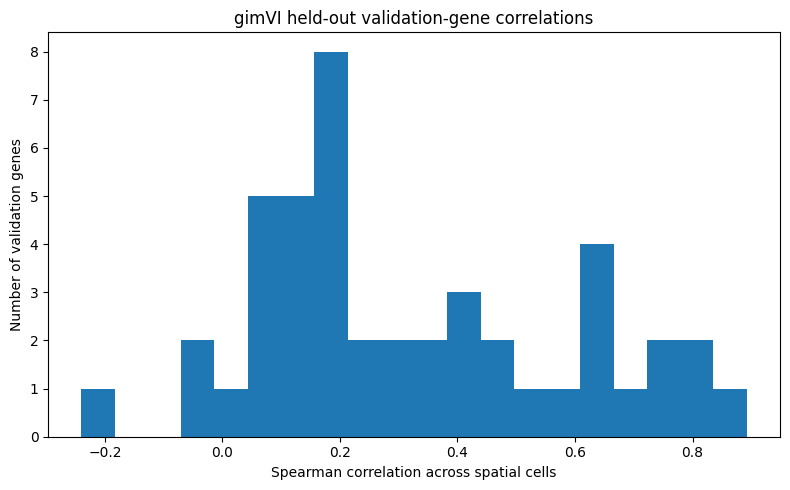

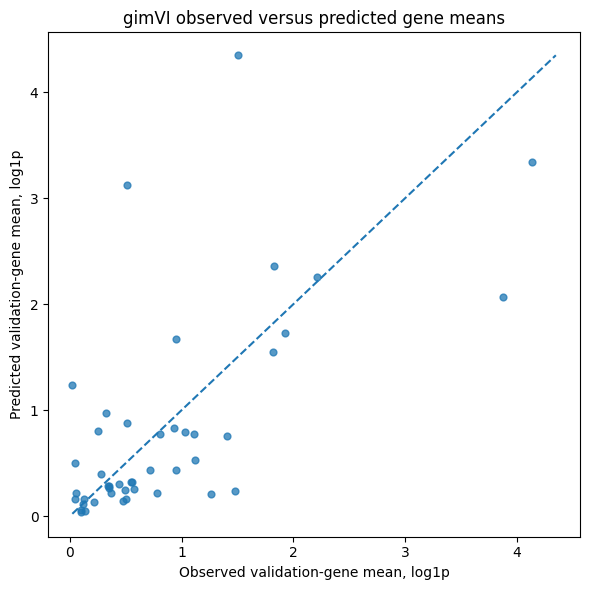

Saved:
/users/mjabin/projects/GeneBridge/outputs/imputation_beta/Br8667/validation/gimvi/figures/13_gimvi_validation_spearman_histogram.png
/users/mjabin/projects/GeneBridge/outputs/imputation_beta/Br8667/validation/gimvi/figures/13_gimvi_observed_vs_predicted_means.png


In [40]:
plt.figure(figsize=(8, 5))
plt.hist(
    gene_metrics["spearman_across_cells"].dropna(),
    bins=20,
)
plt.xlabel("Spearman correlation across spatial cells")
plt.ylabel("Number of validation genes")
plt.title("gimVI held-out validation-gene correlations")
plt.tight_layout()

SPEARMAN_FIGURE_PATH = (
    FIGURE_DIR / "13_gimvi_validation_spearman_histogram.png"
)

plt.savefig(SPEARMAN_FIGURE_PATH, dpi=200)
plt.show()
plt.close()


plt.figure(figsize=(6, 6))

x = np.log1p(gene_metrics["observed_mean"].clip(lower=0))
y = np.log1p(gene_metrics["predicted_mean"].clip(lower=0))

plt.scatter(x, y, s=24, alpha=0.75)

lower = min(float(x.min()), float(y.min()))
upper = max(float(x.max()), float(y.max()))

plt.plot([lower, upper], [lower, upper], linestyle="--")
plt.xlabel("Observed validation-gene mean, log1p")
plt.ylabel("Predicted validation-gene mean, log1p")
plt.title("gimVI observed versus predicted gene means")
plt.tight_layout()

MEAN_FIGURE_PATH = (
    FIGURE_DIR / "13_gimvi_observed_vs_predicted_means.png"
)

plt.savefig(MEAN_FIGURE_PATH, dpi=200)
plt.show()
plt.close()

print("Saved:")
print(SPEARMAN_FIGURE_PATH)
print(MEAN_FIGURE_PATH)


Validation genes selected for spatial plots:
['MTRNR2L12', 'MT-ND4', 'OGA', 'KIF1A']


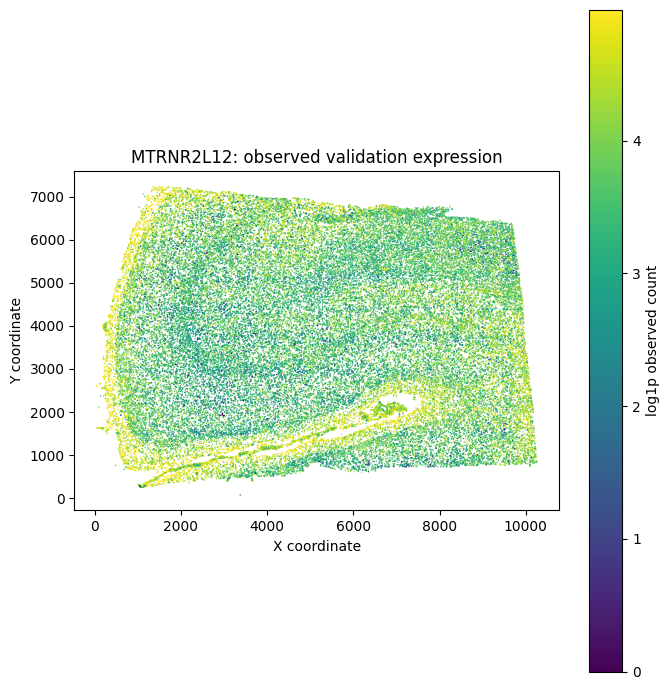

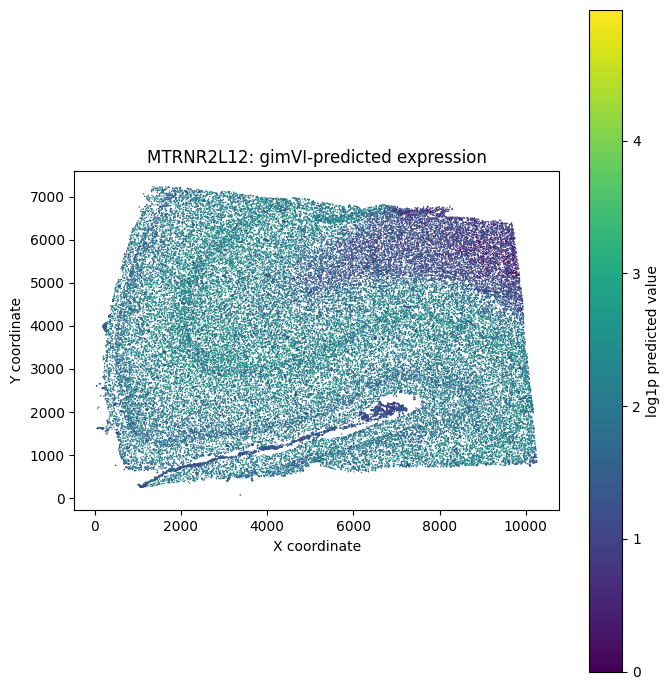

/users/mjabin/projects/GeneBridge/outputs/imputation_beta/Br8667/validation/gimvi/figures/13_MTRNR2L12_observed_spatial.png
/users/mjabin/projects/GeneBridge/outputs/imputation_beta/Br8667/validation/gimvi/figures/13_MTRNR2L12_predicted_spatial.png


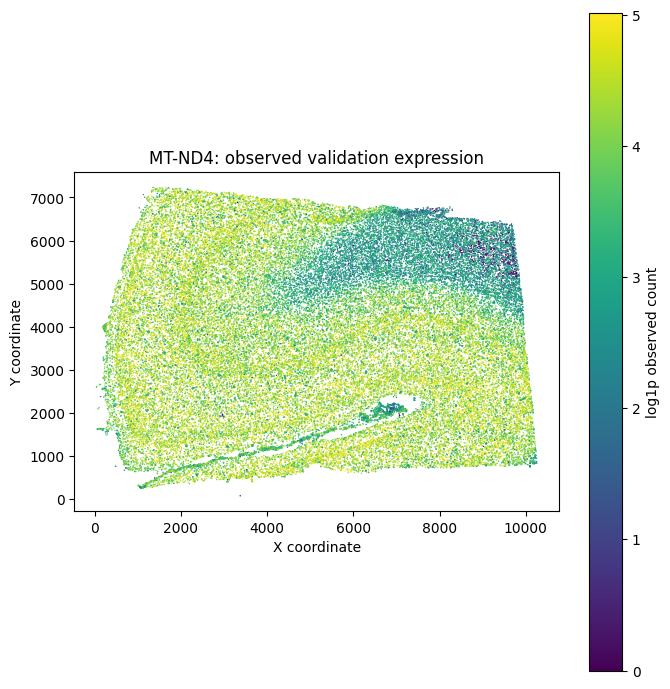

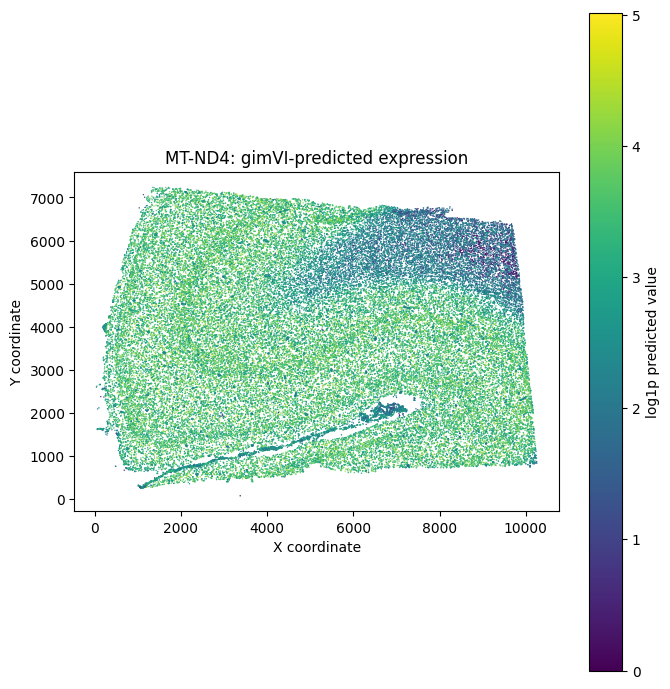

/users/mjabin/projects/GeneBridge/outputs/imputation_beta/Br8667/validation/gimvi/figures/13_MT-ND4_observed_spatial.png
/users/mjabin/projects/GeneBridge/outputs/imputation_beta/Br8667/validation/gimvi/figures/13_MT-ND4_predicted_spatial.png


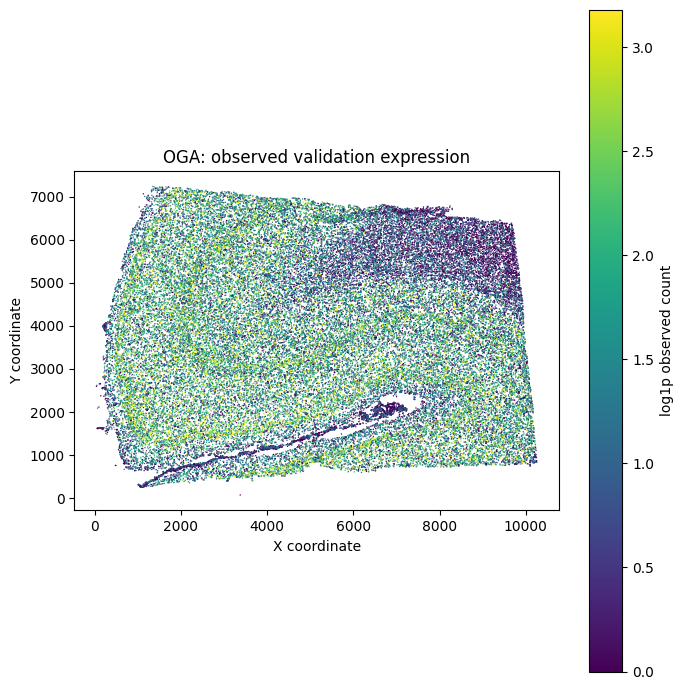

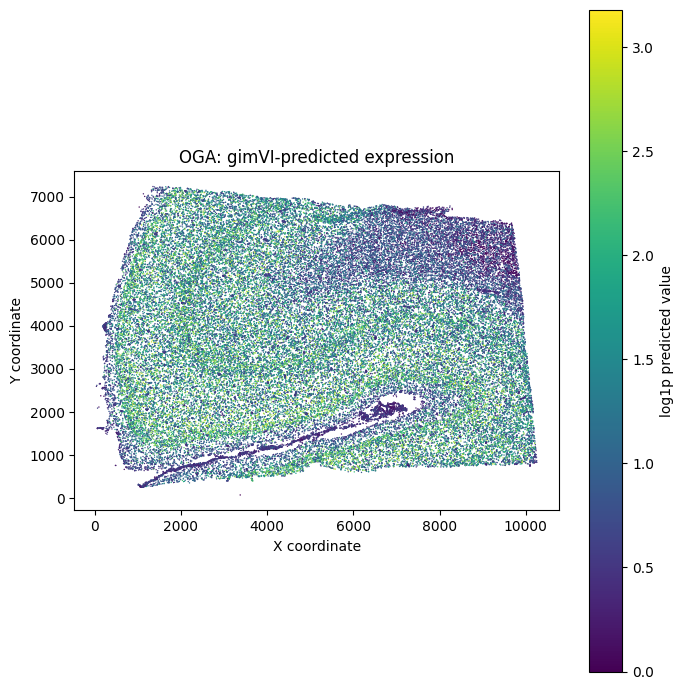

/users/mjabin/projects/GeneBridge/outputs/imputation_beta/Br8667/validation/gimvi/figures/13_OGA_observed_spatial.png
/users/mjabin/projects/GeneBridge/outputs/imputation_beta/Br8667/validation/gimvi/figures/13_OGA_predicted_spatial.png


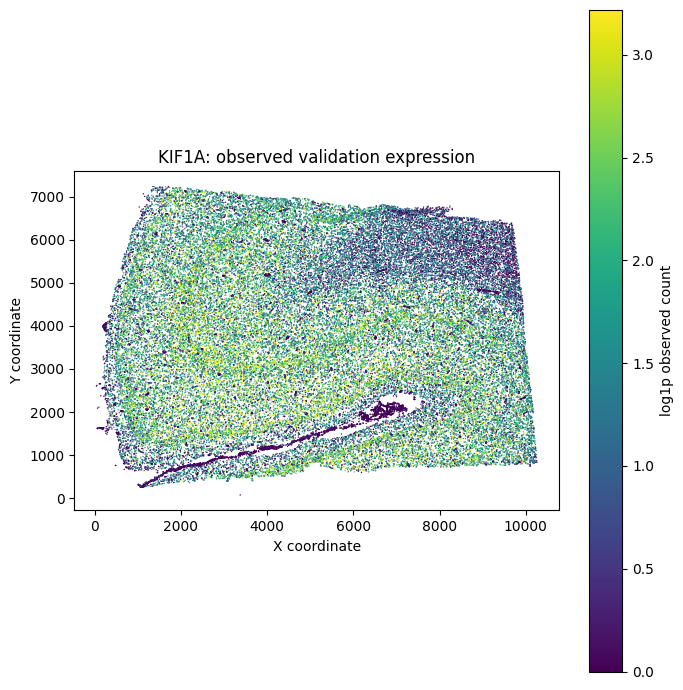

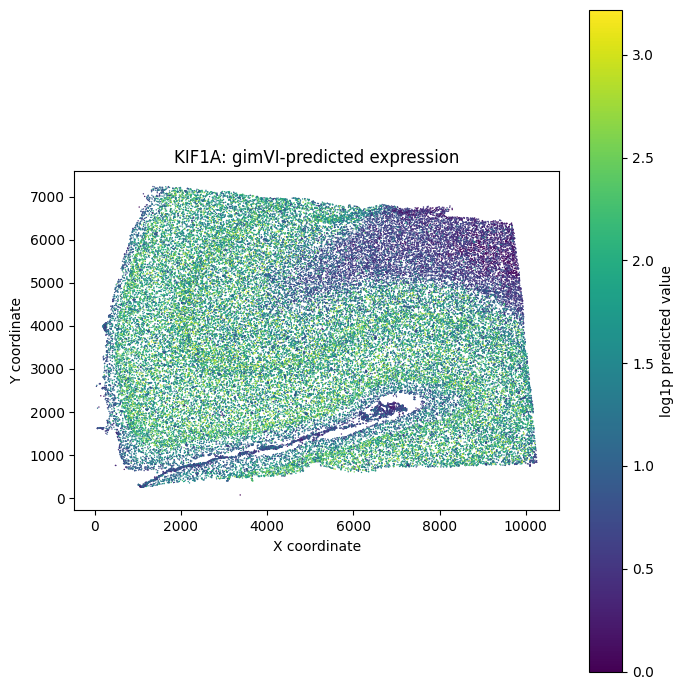

/users/mjabin/projects/GeneBridge/outputs/imputation_beta/Br8667/validation/gimvi/figures/13_KIF1A_observed_spatial.png
/users/mjabin/projects/GeneBridge/outputs/imputation_beta/Br8667/validation/gimvi/figures/13_KIF1A_predicted_spatial.png


In [41]:
spatial_examples = (
    gene_metrics.sort_values(
        ["observed_nonzero_fraction", "observed_variance"],
        ascending=False,
    )
    .head(N_VALIDATION_GENES_TO_PLOT)["gene"]
    .tolist()
)

coordinates = np.asarray(spatial_train.obsm["spatial"])
x_coordinate = coordinates[:, 0]
y_coordinate = coordinates[:, 1]

print("Validation genes selected for spatial plots:")
print(spatial_examples)

for gene in spatial_examples:
    gene_index = validation_genes.index(gene)

    observed_values = np.log1p(
        np.clip(observed_validation[:, gene_index], 0, None)
    )
    predicted_values = np.log1p(
        np.clip(validation_prediction[:, gene_index], 0, None)
    )

    combined_positive = np.concatenate(
        [
            observed_values[observed_values > 0],
            predicted_values[predicted_values > 0],
        ]
    )

    shared_vmax = (
        float(np.quantile(combined_positive, 0.99))
        if combined_positive.size > 0
        else 1.0
    )

    if not np.isfinite(shared_vmax) or shared_vmax <= 0:
        shared_vmax = 1.0

    plt.figure(figsize=(7, 7))
    scatter = plt.scatter(
        x_coordinate,
        y_coordinate,
        c=observed_values,
        s=1,
        linewidths=0,
        rasterized=True,
        vmin=0,
        vmax=shared_vmax,
    )
    plt.gca().set_aspect("equal")
    plt.xlabel("X coordinate")
    plt.ylabel("Y coordinate")
    plt.title(f"{gene}: observed validation expression")
    plt.colorbar(scatter, label="log1p observed count")
    plt.tight_layout()

    observed_path = FIGURE_DIR / f"13_{gene}_observed_spatial.png"
    plt.savefig(observed_path, dpi=220)
    plt.show()
    plt.close()

    plt.figure(figsize=(7, 7))
    scatter = plt.scatter(
        x_coordinate,
        y_coordinate,
        c=predicted_values,
        s=1,
        linewidths=0,
        rasterized=True,
        vmin=0,
        vmax=shared_vmax,
    )
    plt.gca().set_aspect("equal")
    plt.xlabel("X coordinate")
    plt.ylabel("Y coordinate")
    plt.title(f"{gene}: gimVI-predicted expression")
    plt.colorbar(scatter, label="log1p predicted value")
    plt.tight_layout()

    predicted_path = FIGURE_DIR / f"13_{gene}_predicted_spatial.png"
    plt.savefig(predicted_path, dpi=220)
    plt.show()
    plt.close()

    print(observed_path)
    print(predicted_path)


## Final blind test — run only after the model configuration is frozen

This section is intentionally disabled by default.

It evaluates the already-trained **210-gene model** on the 45 blind test genes.
Do not run it while selecting hyperparameters or comparing development settings.

To unlock it, set all three values in the configuration cell:

```python
RUN_BLIND_TEST = True
FINAL_CONFIGURATION_FROZEN = True
BLIND_TEST_CONFIRMATION = "RUN FINAL BLIND TEST"
```

For the stricter final protocol in which all methods are retrained using
`210 train + 45 validation = 255` measured genes, do not use this section until
that 255-gene model has been trained.


RUNNING THE FINAL BLIND TEST



Blind-test checks:
test_gene_count_is_45: True
test_cells_match_spatial_training: True
all_test_genes_in_snrna: True
test_disjoint_from_training: True
test_disjoint_from_validation: True
test_split_csv_matches_truth: True
Processed 128/66,154 spatial cells
Processed 3,200/66,154 spatial cells
Processed 6,400/66,154 spatial cells
Processed 9,600/66,154 spatial cells
Processed 12,800/66,154 spatial cells
Processed 16,000/66,154 spatial cells
Processed 19,200/66,154 spatial cells
Processed 22,400/66,154 spatial cells
Processed 25,600/66,154 spatial cells
Processed 28,800/66,154 spatial cells
Processed 32,000/66,154 spatial cells
Processed 35,200/66,154 spatial cells
Processed 38,400/66,154 spatial cells
Processed 41,600/66,154 spatial cells
Processed 44,800/66,154 spatial cells
Processed 48,000/66,154 spatial cells
Processed 51,200/66,154 spatial cells
Processed 54,400/66,154 spatial cells
Processed 57,600/66,154 spatial cells
Processed 60,800/66,154 spatial cells
Processed 64,000/66,154

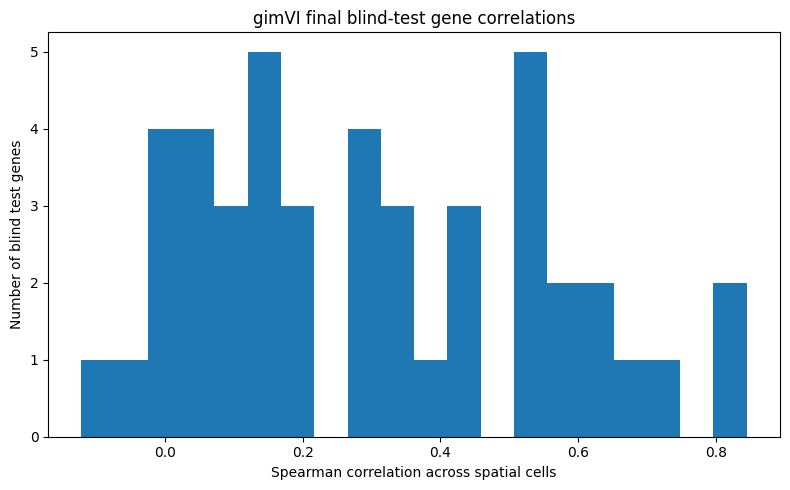

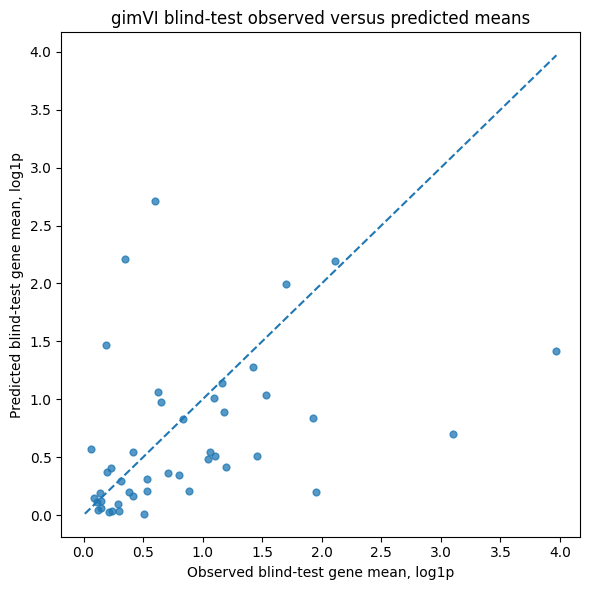


Final blind-test summary:


,metric,value
0,n_blind_test_genes,45.000000
1,median_spearman_across_genes,0.289306
2,median_pearson_log1p_across_genes,0.224975
3,median_mae_log1p_across_genes,0.463192
4,median_rmse_log1p_across_genes,0.615092
5,all_zero_predicted_cells,0.000000
6,all_zero_predicted_genes,0.000000
7,prediction_seconds,3.366819



Saved final blind-test outputs:
/users/mjabin/projects/GeneBridge/data/processed/imputation_beta/Br8667/benchmark/predictions/gimvi_test_predictions_45genes.h5ad
/users/mjabin/projects/GeneBridge/outputs/imputation_beta/Br8667/test/gimvi/14_gimvi_blind_test_gene_metrics.csv
/users/mjabin/projects/GeneBridge/outputs/imputation_beta/Br8667/test/gimvi/14_gimvi_blind_test_summary.csv
/users/mjabin/projects/GeneBridge/outputs/imputation_beta/Br8667/test/gimvi/14_gimvi_blind_test_scClassify_pseudobulk.csv
/users/mjabin/projects/GeneBridge/outputs/imputation_beta/Br8667/test/gimvi/14_gimvi_blind_test_layer_pseudobulk.csv
/users/mjabin/projects/GeneBridge/outputs/imputation_beta/Br8667/test/gimvi/figures/14_gimvi_blind_test_spearman_histogram.png
/users/mjabin/projects/GeneBridge/outputs/imputation_beta/Br8667/test/gimvi/figures/14_gimvi_blind_test_observed_vs_predicted_means.png


In [42]:
# This entire cell is protected by a three-part safety gate.
RUN_MODE = "full"
BLIND_TEST_CONFIRMATION = "RUN FINAL BLIND TEST"
RUN_LATENT_UMAP = True
if not RUN_BLIND_TEST:
    print(
        "Blind test skipped. "
        "RUN_BLIND_TEST is False."
    )

else:
    if RUN_MODE != "full":
        raise RuntimeError(
            "Blind testing is disabled for a smoke-test model. "
            "Set RUN_MODE='full' and train the final model first."
        )

    if not FINAL_CONFIGURATION_FROZEN:
        raise RuntimeError(
            "The final configuration is not marked as frozen."
        )

    if BLIND_TEST_CONFIRMATION != BLIND_TEST_REQUIRED_PHRASE:
        raise RuntimeError(
            "Blind-test confirmation phrase is incorrect. "
            f'Enter exactly: "{BLIND_TEST_REQUIRED_PHRASE}"'
        )

    if not model.is_trained:
        raise RuntimeError(
            "The gimVI model is not trained."
        )

    for required_path in [
        TEST_TRUTH_PATH,
        TEST_SPLIT_PATH,
    ]:
        if not required_path.exists():
            raise FileNotFoundError(required_path)

    print("=" * 100)
    print("RUNNING THE FINAL BLIND TEST")
    print("=" * 100)

    # ---------------------------------------------------------------------
    # Load and align blind truth only after the safety gate has passed.
    # ---------------------------------------------------------------------
    test_truth = ad.read_h5ad(
        TEST_TRUTH_PATH
    )

    test_split = pd.read_csv(
        TEST_SPLIT_PATH
    )

    missing_test_cells = (
        spatial_train.obs_names.difference(
            test_truth.obs_names
        )
    )

    if len(missing_test_cells) > 0:
        raise ValueError(
            f"{len(missing_test_cells)} benchmark cells "
            "are missing from test truth."
        )

    test_truth = test_truth[
        spatial_train.obs_names
    ].copy()

    test_genes = (
        test_truth.var_names
        .astype(str)
        .tolist()
    )

    blind_checks = {
        "test_gene_count_is_45":
            test_truth.n_vars == 45,
        "test_cells_match_spatial_training":
            test_truth.obs_names.equals(
                spatial_train.obs_names
            ),
        "all_test_genes_in_snrna":
            set(test_genes).issubset(
                set(seq_data.var_names.astype(str))
            ),
        "test_disjoint_from_training":
            set(test_genes).isdisjoint(
                set(spatial_train.var_names.astype(str))
            ),
        "test_disjoint_from_validation":
            set(test_genes).isdisjoint(
                set(validation_truth.var_names.astype(str))
            ),
        "test_split_csv_matches_truth":
            set(test_genes)
            == set(
                test_split["gene"]
                .astype(str)
                .tolist()
            ),
    }

    print("\nBlind-test checks:")
    for check_name, passed in blind_checks.items():
        print(f"{check_name}: {passed}")

    if not all(blind_checks.values()):
        failed = [
            check_name
            for check_name, passed in blind_checks.items()
            if not passed
        ]

        raise ValueError(
            f"Blind-test checks failed: {failed}"
        )

    # ---------------------------------------------------------------------
    # Predict the 45 blind genes.
    # ---------------------------------------------------------------------
    test_prediction_start = time.time()

    test_prediction = (
        predict_selected_spatial_genes_in_chunks(
            model=model,
            seq_adata=seq_data,
            spatial_adata=spatial_train,
            selected_genes=test_genes,
            normalized=NORMALIZED_PREDICTIONS,
            batch_size=BATCH_SIZE,
            cell_chunk_size=PREDICTION_CELL_CHUNK_SIZE,
        )
    )

    test_prediction_seconds = (
        time.time() - test_prediction_start
    )

    if not np.isfinite(test_prediction).all():
        raise ValueError(
            "Blind-test predictions contain NaN or infinity."
        )

    if np.any(test_prediction < 0):
        raise ValueError(
            "Blind-test predictions contain negative values."
        )

    print(
        "\nBlind-test prediction shape:",
        test_prediction.shape,
    )

    print(
        f"Blind-test prediction completed in "
        f"{test_prediction_seconds / 60:.2f} minutes."
    )

    # ---------------------------------------------------------------------
    # Save predictions.
    # ---------------------------------------------------------------------
    BLIND_REPORT_DIR = (
        OUTPUT_ROOT / "test/gimvi"
    )

    BLIND_FIGURE_DIR = (
        BLIND_REPORT_DIR / "figures"
    )

    BLIND_REPORT_DIR.mkdir(
        parents=True,
        exist_ok=True,
    )

    BLIND_FIGURE_DIR.mkdir(
        parents=True,
        exist_ok=True,
    )

    BLIND_PREDICTION_PATH = (
        PREDICTION_DIR
        / "gimvi_test_predictions_45genes.h5ad"
    )

    test_prediction_adata = ad.AnnData(
        X=test_prediction.astype(
            np.float32,
            copy=False,
        ),
        obs=spatial_train.obs.copy(),
        var=test_truth.var.copy(),
    )

    test_prediction_adata.obsm["spatial"] = (
        spatial_train.obsm["spatial"].copy()
    )

    test_prediction_adata.uns["method"] = (
        "standard_gimVI"
    )

    test_prediction_adata.uns["benchmark_role"] = (
        "blind_test_prediction"
    )

    test_prediction_adata.uns[
        "training_spatial_genes"
    ] = int(spatial_train.n_vars)

    test_prediction_adata.uns[
        "blind_test_genes"
    ] = int(test_truth.n_vars)

    test_prediction_adata.uns[
        "normalized_predictions"
    ] = bool(NORMALIZED_PREDICTIONS)

    test_prediction_adata.write_h5ad(
        BLIND_PREDICTION_PATH,
        compression="gzip",
    )

    # ---------------------------------------------------------------------
    # Calculate final blind-test metrics.
    # ---------------------------------------------------------------------
    observed_test = to_numpy(
        test_truth.X,
        dtype=np.float32,
    )

    test_gene_metrics = calculate_gene_metrics(
        observed=observed_test,
        predicted=test_prediction,
        genes=test_genes,
    )

    merge_columns = [
        column
        for column in [
            "gene",
            "expression_stratum",
            "expression_stratum_number",
            "mean_expression",
            "detection_fraction",
        ]
        if column in test_split.columns
    ]

    test_gene_metrics = test_gene_metrics.merge(
        test_split[merge_columns],
        on="gene",
        how="left",
        suffixes=("", "_split"),
    )

    TEST_GENE_METRICS_PATH = (
        BLIND_REPORT_DIR
        / "14_gimvi_blind_test_gene_metrics.csv"
    )

    test_gene_metrics.to_csv(
        TEST_GENE_METRICS_PATH,
        index=False,
    )

    test_summary = pd.DataFrame(
        [
            {
                "metric": "n_blind_test_genes",
                "value": len(test_gene_metrics),
            },
            {
                "metric": "median_spearman_across_genes",
                "value": test_gene_metrics[
                    "spearman_across_cells"
                ].median(skipna=True),
            },
            {
                "metric": "median_pearson_log1p_across_genes",
                "value": test_gene_metrics[
                    "pearson_log1p_across_cells"
                ].median(skipna=True),
            },
            {
                "metric": "median_mae_log1p_across_genes",
                "value": test_gene_metrics[
                    "mae_log1p"
                ].median(skipna=True),
            },
            {
                "metric": "median_rmse_log1p_across_genes",
                "value": test_gene_metrics[
                    "rmse_log1p"
                ].median(skipna=True),
            },
            {
                "metric": "all_zero_predicted_cells",
                "value": int(
                    np.sum(
                        test_prediction.sum(axis=1) == 0
                    )
                ),
            },
            {
                "metric": "all_zero_predicted_genes",
                "value": int(
                    np.sum(
                        test_prediction.sum(axis=0) == 0
                    )
                ),
            },
            {
                "metric": "prediction_seconds",
                "value": test_prediction_seconds,
            },
        ]
    )

    TEST_SUMMARY_PATH = (
        BLIND_REPORT_DIR
        / "14_gimvi_blind_test_summary.csv"
    )

    test_summary.to_csv(
        TEST_SUMMARY_PATH,
        index=False,
    )

    # ---------------------------------------------------------------------
    # Final blind-test pseudobulk metrics.
    # ---------------------------------------------------------------------
    test_celltype_metrics = (
        calculate_pseudobulk_metrics(
            observed=observed_test,
            predicted=test_prediction,
            genes=test_genes,
            metadata=spatial_train.obs,
            group_column="scClassify",
        )
    )

    test_layer_metrics = (
        calculate_pseudobulk_metrics(
            observed=observed_test,
            predicted=test_prediction,
            genes=test_genes,
            metadata=spatial_train.obs,
            group_column="layer_annotation",
        )
    )

    TEST_CELLTYPE_METRICS_PATH = (
        BLIND_REPORT_DIR
        / "14_gimvi_blind_test_scClassify_pseudobulk.csv"
    )

    TEST_LAYER_METRICS_PATH = (
        BLIND_REPORT_DIR
        / "14_gimvi_blind_test_layer_pseudobulk.csv"
    )

    test_celltype_metrics.to_csv(
        TEST_CELLTYPE_METRICS_PATH,
        index=False,
    )

    test_layer_metrics.to_csv(
        TEST_LAYER_METRICS_PATH,
        index=False,
    )

    # ---------------------------------------------------------------------
    # Save final blind-test figures.
    # ---------------------------------------------------------------------
    plt.figure(figsize=(8, 5))
    plt.hist(
        test_gene_metrics[
            "spearman_across_cells"
        ].dropna(),
        bins=20,
    )
    plt.xlabel(
        "Spearman correlation across spatial cells"
    )
    plt.ylabel(
        "Number of blind test genes"
    )
    plt.title(
        "gimVI final blind-test gene correlations"
    )
    plt.tight_layout()

    TEST_SPEARMAN_FIGURE_PATH = (
        BLIND_FIGURE_DIR
        / "14_gimvi_blind_test_spearman_histogram.png"
    )

    plt.savefig(
        TEST_SPEARMAN_FIGURE_PATH,
        dpi=200,
    )
    plt.show()
    plt.close()

    plt.figure(figsize=(6, 6))

    x = np.log1p(
        test_gene_metrics[
            "observed_mean"
        ].clip(lower=0)
    )

    y = np.log1p(
        test_gene_metrics[
            "predicted_mean"
        ].clip(lower=0)
    )

    plt.scatter(
        x,
        y,
        s=24,
        alpha=0.75,
    )

    lower = min(
        float(x.min()),
        float(y.min()),
    )

    upper = max(
        float(x.max()),
        float(y.max()),
    )

    plt.plot(
        [lower, upper],
        [lower, upper],
        linestyle="--",
    )

    plt.xlabel(
        "Observed blind-test gene mean, log1p"
    )

    plt.ylabel(
        "Predicted blind-test gene mean, log1p"
    )

    plt.title(
        "gimVI blind-test observed versus predicted means"
    )

    plt.tight_layout()

    TEST_MEAN_FIGURE_PATH = (
        BLIND_FIGURE_DIR
        / "14_gimvi_blind_test_observed_vs_predicted_means.png"
    )

    plt.savefig(
        TEST_MEAN_FIGURE_PATH,
        dpi=200,
    )
    plt.show()
    plt.close()

    print("\nFinal blind-test summary:")
    display(test_summary)

    print("\nSaved final blind-test outputs:")
    for path in [
        BLIND_PREDICTION_PATH,
        TEST_GENE_METRICS_PATH,
        TEST_SUMMARY_PATH,
        TEST_CELLTYPE_METRICS_PATH,
        TEST_LAYER_METRICS_PATH,
        TEST_SPEARMAN_FIGURE_PATH,
        TEST_MEAN_FIGURE_PATH,
    ]:
        print(path)


## 16. Optional tutorial-style latent-space UMAP

This is not required for the held-out-gene benchmark. It checks whether sequencing nuclei and spatial cells occupy a jointly learned latent space.


/scratch/mjabin/conda_envs/Imputation/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


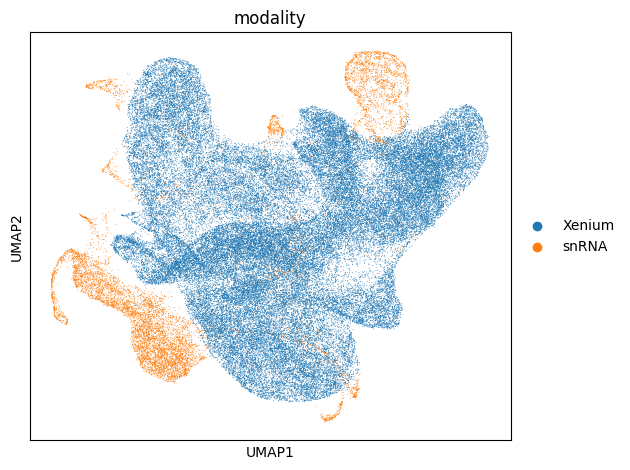

Saved:
/users/mjabin/projects/GeneBridge/outputs/imputation_beta/Br8667/validation/gimvi/figures/12_gimvi_joint_latent_umap.png


In [43]:
if RUN_LATENT_UMAP:
    latent_seq, latent_spatial = model.get_latent_representation(
        deterministic=True,
        batch_size=BATCH_SIZE,
    )

    latent_matrix = np.concatenate(
        [latent_seq, latent_spatial],
        axis=0,
    )

    latent_adata = ad.AnnData(X=latent_matrix)
    latent_adata.obs["modality"] = (
        ["snRNA"] * latent_seq.shape[0]
        + ["Xenium"] * latent_spatial.shape[0]
    )

    sc.pp.neighbors(latent_adata, use_rep="X")
    sc.tl.umap(latent_adata, random_state=RANDOM_SEED)
    sc.pl.umap(latent_adata, color="modality", show=False)

    LATENT_FIGURE_PATH = (
        FIGURE_DIR / "12_gimvi_joint_latent_umap.png"
    )

    plt.tight_layout()
    plt.savefig(LATENT_FIGURE_PATH, dpi=200)
    plt.show()
    plt.close()

    print("Saved:")
    print(LATENT_FIGURE_PATH)
else:
    print("RUN_LATENT_UMAP=False; skipping optional latent UMAP.")


## 17. Final output inventory

A successful full run creates:
- saved standard gimVI model;
- retained development-cell list;
- 45-gene validation prediction h5ad;
- per-gene and summary validation metrics;
- cell-type and layer pseudobulk metrics;
- validation plots.

The blind test truth remains unused.


In [44]:
created_outputs = [
    MODEL_DIR,
    DEVELOPMENT_CELL_IDS_PATH,
    PREDICTION_PATH,
    RUN_METADATA_PATH,
    GENE_METRICS_PATH,
    SUMMARY_PATH,
    CELLTYPE_METRICS_PATH,
    LAYER_METRICS_PATH,
    SPEARMAN_FIGURE_PATH,
    MEAN_FIGURE_PATH,
]

print("=" * 100)
print("gimVI Br8667 validation workflow completed")
print("=" * 100)

for path in created_outputs:
    print(f"{'EXISTS' if path.exists() else 'MISSING'}: {path}")

if RUN_BLIND_TEST:
    print(
        "\nBlind-test execution was requested. "
        "Review the dedicated blind-test section output."
    )
else:
    print(
        "\nBlind test remains locked and was not evaluated."
    )


gimVI Br8667 validation workflow completed
EXISTS: /users/mjabin/projects/GeneBridge/outputs/imputation_beta/Br8667/models/gimvi_train210_smoke
EXISTS: /users/mjabin/projects/GeneBridge/data/processed/imputation_beta/Br8667/benchmark/splits/development_cell_ids.csv
EXISTS: /users/mjabin/projects/GeneBridge/data/processed/imputation_beta/Br8667/benchmark/predictions/gimvi_validation_predictions_45genes_smoke.h5ad
EXISTS: /users/mjabin/projects/GeneBridge/outputs/imputation_beta/Br8667/validation/gimvi/12_gimvi_run_metadata.csv
EXISTS: /users/mjabin/projects/GeneBridge/outputs/imputation_beta/Br8667/validation/gimvi/13_gimvi_validation_gene_metrics.csv
EXISTS: /users/mjabin/projects/GeneBridge/outputs/imputation_beta/Br8667/validation/gimvi/13_gimvi_validation_summary.csv
EXISTS: /users/mjabin/projects/GeneBridge/outputs/imputation_beta/Br8667/validation/gimvi/13_gimvi_validation_scClassify_pseudobulk.csv
EXISTS: /users/mjabin/projects/GeneBridge/outputs/imputation_beta/Br8667/validation